In [1]:
# Check if backend is available
import sys
print("Python executable:", sys.executable)

try:
    from src_tensor import _pps_tensor_backend
    print("Backend loaded successfully!")
    print("Backend location:", _pps_tensor_backend.__file__)
except ImportError as e:
    print("Backend import failed:", e)

Python executable: /home/ubuntu/miniconda3/envs/ENV_311/bin/python
Backend import failed: /home/ubuntu/miniconda3/envs/ENV_311/lib/python3.11/site-packages/src_tensor/_pps_tensor_backend.so: undefined symbol: _ZN3c105ErrorC2ENS_14SourceLocationESs


# Tutorial: Pauli Propagation Surrogate
This tutorial summarizes the overall workflow: **data types**, the **propagation process**, **how to propagate through a quantum circuit**, and the **training loop**.

## 1) Data Types
Below is an overview of the key data types and their roles.

- **PauliString**: Represents a Pauli operator as bitmasks (e.g., X/Z masks).
- **PauliSum**: A weighted sum of PauliStrings (Hamiltonian / observable).
- **TensorPauliSum**: A tensor-based representation for GPU execution (x_mask/z_mask, coeff_init, steps).
- **TensorSparseStep**: Stores the effect of a single gate on the Pauli sum as sparse matrices (constant / cosine / sine parts).
- **TensorSparseEvaluator**: Evaluates coefficients of a TensorPauliSum to compute an expectation value or loss.

Summary: define the problem as a `PauliSum`, build a `TensorPauliSum` via `propagate_surrogate_tensor`, then evaluate via `TensorSparseEvaluator`.

## 2) Propagation Overview
`propagate_surrogate_tensor` iterates over the circuit **in reverse order** and converts an observable (`PauliSum`) into a tensor-native `TensorPauliSum`.

- Each gate is converted into a `TensorSparseStep`.
- A `TensorSparseStep` represents coefficient updates using **sparse matrix operations**.
- It can be evaluated efficiently on GPU using sparse tensor ops.

Core idea: instead of simulating the circuit state, we accumulate **Pauli-term rewrite rules** as a chain of sparse linear maps.

## 3) How Pauli terms are propagated through the circuit
For each gate, we apply deterministic rewrite rules describing how Pauli terms change.

- **CliffordGate**: X/Z bitmasks are updated according to Clifford conjugation rules. Coefficients may pick up sign changes.
- **PauliRotation**: Depending on commutation vs anti-commutation, the term branches into constant / cosine / sine contributions.
- These transformations are recorded as `TensorSparseStep`, so the full circuit becomes a sparse-matrix chain.

Optional truncation controls (to trade accuracy for speed):
- `max_weight`, `max_xy`: limit term complexity to control growth.
- `min_abs` + `thetas`: apply absolute-value truncation around a given parameter point (useful during training).

## 4) Training Workflow
A typical training loop follows these steps:

1. **Build the surrogate**: create a `TensorPauliSum` via `propagate_surrogate_tensor`
2. **Zero-filter (optional)**: keep only diagonal terms via `zero_filter_tensor_backprop` for computational-basis expectations
3. **Evaluate coefficients**: use `TensorSparseEvaluator` to compute coefficients and the expectation value
4. **Optimize**: update `thetas` based on the expectation (or loss)
5. **(Optional) 2-step truncation**:
   - Stage 1: train with a looser truncation to reach a meaningful parameter region
   - Stage 2: re-run propagation with `min_abs` absolute-value truncation around the trained `thetas`, then fine-tune
   - Rationale: early in training, parameters are essentially random, so truncation based on coefficient magnitudes can be unstable; applying stronger truncation near a trained solution is typically more reliable.

Summary: once parameters become meaningful, apply stronger truncation to improve speed while keeping accuracy.

## 5) Minimal Execution Flow (Pseudo-steps)
Below is a minimal end-to-end outline of the pipeline:

1. Build the observable as a `PauliSum`
2. Prepare the circuit as a list of `CliffordGate` / `PauliRotation`
3. Run `propagate_surrogate_tensor(...)` to produce a `TensorPauliSum`
4. Optionally apply `zero_filter_tensor_backprop(...)`
5. Use `TensorSparseEvaluator` to compute the expectation value
6. Update `thetas` with an optimizer
7. (Optional) Re-propagate and fine-tune using `min_abs` truncation around the trained `thetas`

## 6) Example Code (Steps 1–5)
The code below is written so that **Steps 1–5 are visible and sequential**.

In [1]:
# Step 0) Imports
import os, sys
import numpy as np
import torch

repo_root = os.path.abspath(os.path.join(os.getcwd(), "."))
if repo_root not in sys.path:
    sys.path.insert(0, repo_root)

from src.pauli_surrogate_python import PauliSum, CliffordGate, PauliRotation, make_pauli_string
from src_tensor import propagate_surrogate_tensor, TensorSparseEvaluator, zero_filter_tensor_backprop

# Step 1) Define observable (PauliSum)
n_qubits = 20
edge_list = [(i,j,1) for i in range(n_qubits) for j in range(i+1, n_qubits)]
obs = PauliSum(n_qubits)
const = 0.0
for (i, j, w) in edge_list:
    const += 0.5 * w
    pauli = ['I'] * n_qubits
    pauli[i] = 'Z'
    pauli[j] = 'Z'
    obs.add(make_pauli_string(''.join(pauli)), -0.5 * w)
obs.add(make_pauli_string('I' * n_qubits), const)

# Step 2) Build circuit (CliffordGate / PauliRotation)
p_layers = 2
circuit = []
param_idx = 0
for _ in range(p_layers):
    for q in range(n_qubits):
        circuit.append(CliffordGate('H', [q]))
    for (i, j, _) in edge_list:
        circuit.append(PauliRotation('ZZ', [i, j], param_idx=param_idx))
    param_idx += 1
    for q in range(n_qubits):
        circuit.append(PauliRotation('X', [q], param_idx=param_idx))
    param_idx += 1
n_params = param_idx

# Step 3) Propagate -> TensorPauliSum
device = "cpu"
psum = propagate_surrogate_tensor(
    circuit=circuit,
    observable=obs,
    device=device,
    dtype="float32",
    max_weight=10,
    thetas= torch.zeros(n_params, device=device, dtype=torch.float32),
    min_abs= 1e-4,
)
psum = zero_filter_tensor_backprop(psum)  # optional (diagonal terms only)

# Step 4) Evaluate expectation (TensorSparseEvaluator)
def surrogate_expectation_tensor(psum_local, thetas):
    evaluator = TensorSparseEvaluator(psum_local)
    coeffs = evaluator.evaluate_coeffs(thetas)
    return torch.sum(coeffs[psum_local.x_mask == 0])

# Step 5) Train (optimize thetas)
torch.manual_seed(0)
params = torch.nn.Parameter(0.1 * torch.randn(n_params, device=device, dtype=torch.float32))
opt = torch.optim.Adam([params], lr=0.1)
from tqdm import tqdm
for step in tqdm(range(50)):
    opt.zero_grad()
    val = surrogate_expectation_tensor(psum, params)
    loss = -val
    loss.backward()
    opt.step()
print("final expval:", float(val.detach().cpu().item()))

100%|██████████| 50/50 [00:04<00:00, 11.75it/s]

final expval: 95.0


In [2]:
# Helpers for CPU vs GPU timing
import time
import numpy as np

try:
    import matplotlib.pyplot as plt
except Exception as e:
    plt = None
    print("matplotlib not available; will skip plots.")
    print("Import error:", repr(e))


def _sync_if_cuda(device: str) -> None:
    if isinstance(device, str) and device.startswith("cuda") and torch.cuda.is_available():
        torch.cuda.synchronize()


def surrogate_expectation_only(psum_local, thetas):
    # Evaluate on whatever device psum_local/thetas already live on.
    evaluator = TensorSparseEvaluator(psum_local, stream_device=None, offload_back=False)
    coeffs = evaluator.evaluate_coeffs(thetas)
    return torch.sum(coeffs[psum_local.x_mask == 0])


propagate: 100%|██████████| 460/460 [04:38<00:00,  1.65it/s] 


[cpu] min_abs=0.01 expval=94.216492 propagate=299.983s eval=0.018s


propagate: 100%|██████████| 460/460 [06:37<00:00,  1.16it/s] 


[cpu] min_abs=0.001 expval=93.642494 propagate=415.571s eval=0.035s


propagate: 100%|██████████| 460/460 [00:07<00:00, 63.90it/s] 


[cuda] min_abs=0.01 expval=94.216476 propagate=8.424s eval=0.156s


propagate: 100%|██████████| 460/460 [00:07<00:00, 64.84it/s]


[cuda] min_abs=0.001 expval=93.642494 propagate=8.396s eval=0.168s


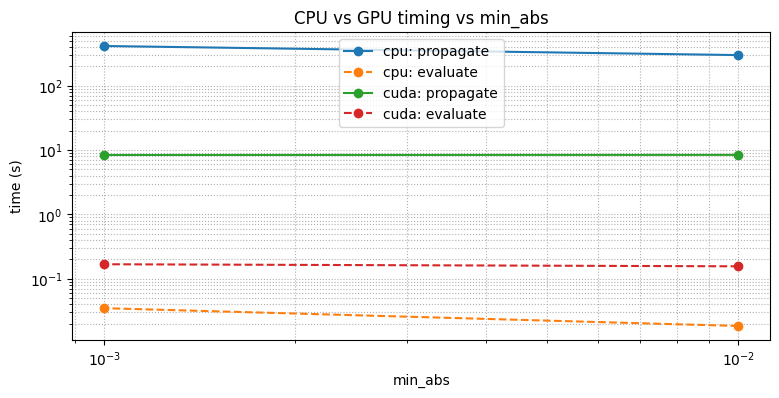

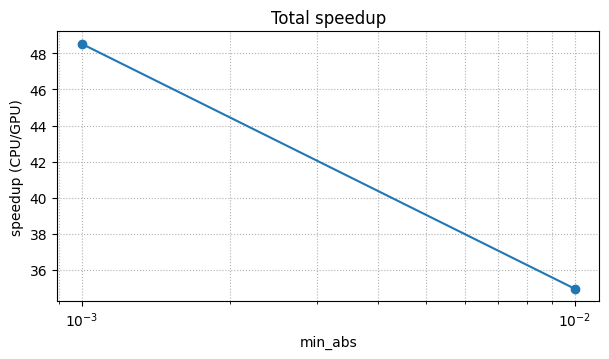

In [3]:
# CPU vs GPU timing sweep for different min_abs values
abs_lists = [1e-2,1e-3]

# Compare CPU vs GPU (if available)
devices_to_test = [("cpu", "cpu")]
if torch.cuda.is_available():
    devices_to_test.append(("cuda", "cuda"))
else:
    print("CUDA not available; running CPU-only.")

results = {}  # label -> dict(min_abs, propagate_s, eval_s, expval)

for label, dev in devices_to_test:
    thetas_dev = params.detach().to(dev)

    # Optional warmup (GPU timing is async; warmup reduces one-time overhead)
    if dev.startswith("cuda"):
        _sync_if_cuda(dev)
        psum_warm = propagate_surrogate_tensor(
            circuit=circuit,
            observable=obs,
            device=dev,
            dtype="float32",
            thetas=thetas_dev,
            min_abs=abs_lists[0],
            max_weight=6,
        )
        psum_warm = zero_filter_tensor_backprop(psum_warm)
        _ = surrogate_expectation_only(psum_warm, thetas_dev)
        _sync_if_cuda(dev)

    prop_times = []
    eval_times = []
    expvals = []

    for abs_min in abs_lists:
        # Time propagation
        _sync_if_cuda(dev)
        t0 = time.perf_counter()
        psum_local = propagate_surrogate_tensor(
            circuit=circuit,
            observable=obs,
            device=dev,
            dtype="float32",
            thetas=thetas_dev,
            min_abs=abs_min,
            max_weight=4,
        )
        psum_local = zero_filter_tensor_backprop(psum_local)  # optional (diagonal terms only)
        _sync_if_cuda(dev)
        t1 = time.perf_counter()

        # Time evaluation
        _sync_if_cuda(dev)
        t2 = time.perf_counter()
        val = surrogate_expectation_only(psum_local, thetas_dev)
        _sync_if_cuda(dev)
        t3 = time.perf_counter()

        prop_s = t1 - t0
        eval_s = t3 - t2
        prop_times.append(prop_s)
        eval_times.append(eval_s)
        expvals.append(float(val.detach().cpu().item()))

        print(
            f"[{label}] min_abs={abs_min:g} expval={expvals[-1]:.6f} "
            f"propagate={prop_s:.3f}s eval={eval_s:.3f}s"
        )

    results[label] = {
        "min_abs": list(abs_lists),
        "propagate_s": prop_times,
        "eval_s": eval_times,
        "expval": expvals,
    }

# Plot timing curves
if plt is not None:
    x = np.array(abs_lists, dtype=float)

    plt.figure(figsize=(9, 4))
    for label in results:
        plt.plot(x, results[label]["propagate_s"], marker="o", label=f"{label}: propagate")
        plt.plot(x, results[label]["eval_s"], marker="o", linestyle="--", label=f"{label}: evaluate")

    plt.xscale("log")
    plt.yscale("log")
    plt.xlabel("min_abs")
    plt.ylabel("time (s)")
    plt.title("CPU vs GPU timing vs min_abs")
    plt.grid(True, which="both", ls=":")
    plt.legend()
    plt.show()

    if "cpu" in results and "cuda" in results:
        cpu_total = np.array(results["cpu"]["propagate_s"]) + np.array(results["cpu"]["eval_s"])
        gpu_total = np.array(results["cuda"]["propagate_s"]) + np.array(results["cuda"]["eval_s"])

        plt.figure(figsize=(7, 3.5))
        plt.plot(x, cpu_total / gpu_total, marker="o")
        plt.xscale("log")
        plt.xlabel("min_abs")
        plt.ylabel("speedup (CPU/GPU)")
        plt.title("Total speedup")
        plt.grid(True, which="both", ls=":")
        plt.show()
